<center><img src="img/aml-logo.png" width="600"/>

***

<center>Lecture 11</center>

***

<center>Time Series </center>

***

<center>28 April 2026<center>
<center>Rahman Peimankar<center>

# Agenda

- Time Series Forecasting
- Time Series Classification

# Recap of Last Week

# Neural Networks

<div>
<center>
<img src="img/Qimage-3-lecture 10.JPG" width="1000"/>
</div>

# Backpropagation

## Main Ideas of Backpropagation

1. Using the **Chain Rule** to calculate derivatives.
2. Plugging the derivatives into **Gradient Descent** to optimize parameters.

In conclusion, **Main Idea** for **Backpropagation** is that when a parameter like $b_3$ is unknown:

* We use the **Chain Rule** to calculate the derivative of the **Sum of the Squared Residulas (SSR)**

    * with respect to the unknown parameters (in this case $b_3$).

* Then we initialize the unknown parameters with a number (in this case we set $b_3 = 0$)

* And used **Gradient Descent** to optimize the unknown parameter

<center> 
<img src="img/Qimage-28-lecture 10.JPG" width="1000"/>

<font size="16"><center>Time Series Forecasting

## Forecasting vs ordinary supervised learning

A time series has **ordered observations**.  
That means:

- nearby points are often correlated
- shuffling rows usually destroys structure
- train/test splitting must respect time order
- evaluation should mimic how forecasting is done in practice

We will focus on **one-step forecasting** first and then show how the same framing extends to richer models.

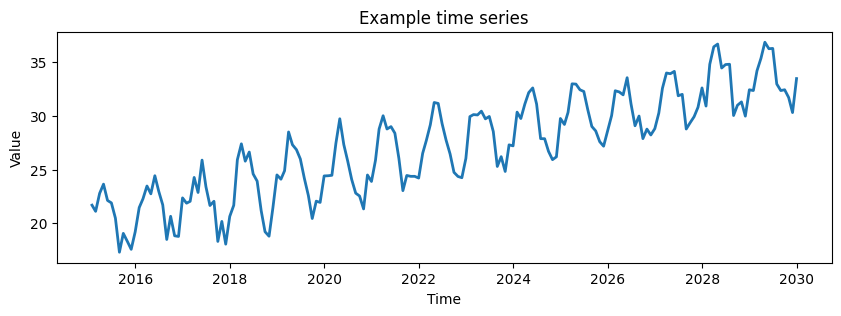

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(7)
# Synthetic series: trend + seasonality + noise
n = 180
t = np.arange(n)
series = pd.Series(20 + 0.08*t + 3*np.sin(2*np.pi*t/12) + np.random.normal(0, 1.0, n),
    index=pd.date_range("2015-01-01", periods=n, freq="ME"), name="value")
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(series.index, series.values, linewidth=2)
ax.set_title("Example time series")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
plt.show()

This plot contains:
- an upward drift over time
- a repeating yearly-like pattern
- noise around the main structure

This is why forecasting is harder than ordinary regression:
the data-generating process changes with time while still retaining structure.

## From sequence to supervised learning

Core idea:

Use past observations as inputs and the next observation as the target.

Example with window size 3:

| lag3 | lag2 | lag1 | target |
|---:|---:|---:|---:|
| 100 | 110 | 108 | 115 |
| 110 | 108 | 115 | 120 |

This is often called:
- lag framing
- sliding window
- supervised transformation of a series

In [7]:
def series_to_supervised(values, n_in=3, n_out=1, dropnan=True):
    data = pd.DataFrame(values)
    cols, names = [], []

    for i in range(n_in, 0, -1):
        cols.append(data.shift(i))
        names += [f"lag_{i}"]

    for i in range(0, n_out):
        cols.append(data.shift(-i))
        names += ["y" if i == 0 else f"y+{i}"]

    agg = pd.concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg = agg.dropna()
    return agg

supervised = series_to_supervised(series.values, n_in=6, n_out=1)
supervised.head(10)

,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,y
6,21.690526,21.114063,22.790896,23.647516,22.129153,21.902066,20.479110
7,21.114063,22.790896,23.647516,22.129153,21.902066,20.479110,17.305276
8,22.790896,23.647516,22.129153,21.902066,20.479110,17.305276,19.059582
9,23.647516,22.129153,21.902066,20.479110,17.305276,19.059582,18.320499
10,22.129153,21.902066,20.479110,17.305276,19.059582,18.320499,17.576495
11,21.902066,20.479110,17.305276,19.059582,18.320499,17.576495,19.208452
12,20.479110,17.305276,19.059582,18.320499,17.576495,19.208452,21.465299
13,17.305276,19.059582,18.320499,17.576495,19.208452,21.465299,22.278644
14,19.059582,18.320499,17.576495,19.208452,21.465299,22.278644,23.475327
15,18.320499,17.576495,19.208452,21.465299,22.278644,23.475327,22.746759


## Why baselines matter

Before using complex models, compare against very simple methods.

Strong baselines help answer:
- Is the problem actually forecastable?
- Is the complex model truly better?
- Are we overfitting?

Common baselines:
- mean forecast
- last value / persistence forecast
- seasonal naive forecast

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def walk_forward_last_value(train, test):
    history = list(train)
    preds = []
    for x in test:
        yhat = history[-1]          # persistence / naive forecast
        preds.append(yhat)
        history.append(x)
    return np.array(preds)

def walk_forward_seasonal_naive(train, test, season=12):
    history = list(train)
    preds = []
    for i, x in enumerate(test):
        if len(history) >= season:
            yhat = history[-season]
        else:
            yhat = history[-1]
        preds.append(yhat)
        history.append(x)
    return np.array(preds)

In [10]:
split = int(len(series) * 0.8)
train, test = series.values[:split], series.values[split:]

pred_last = walk_forward_last_value(train, test)
pred_seasonal = walk_forward_seasonal_naive(train, test, season=12)

def metrics(y_true, y_pred, name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    return pd.Series({"model": name, "MAE": mae, "RMSE": rmse})

baseline_results = pd.DataFrame([
    metrics(test, pred_last, "Persistence (last value)"),
    metrics(test, pred_seasonal, "Seasonal naive (lag 12)")
])

baseline_results

,model,MAE,RMSE
0,Persistence (last value),1.369994,1.814346
1,Seasonal naive (lag 12),1.446268,1.718300


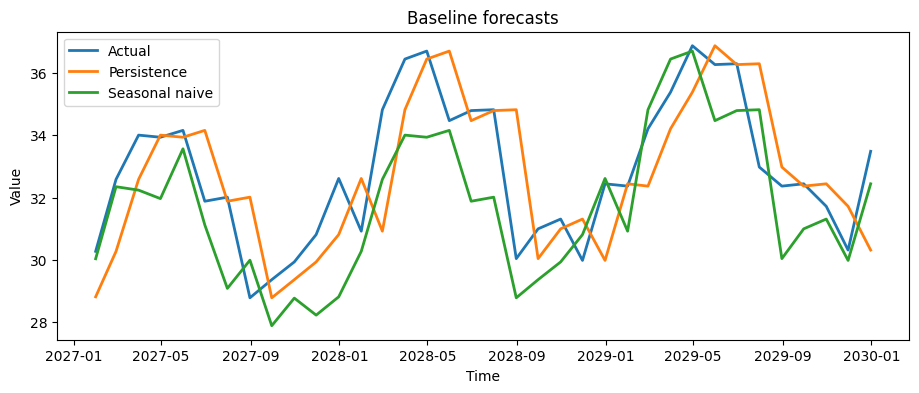

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(series.index[-len(test):], test, label="Actual", linewidth=2)
ax.plot(series.index[-len(test):], pred_last, label="Persistence", linewidth=2)
ax.plot(series.index[-len(test):], pred_seasonal, label="Seasonal naive", linewidth=2)
ax.set_title("Baseline forecasts")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
plt.show()

## Tree-based forecasting: Random Forest

A random forest can work well when we frame the time series as a tabular supervised learning problem.

**Advantages**:
- nonlinear
- robust
- little feature scaling required
- can capture interactions across lagged inputs

**Limitations**:
- does not naturally extrapolate trend
- needs careful lag engineering

In [13]:
from sklearn.ensemble import RandomForestRegressor

def make_supervised_train_test(values, n_lags=12, train_ratio=0.8):
    df = series_to_supervised(values, n_in=n_lags, n_out=1)
    X = df.drop(columns=["y"]).values
    y = df["y"].values
    split = int(len(df) * train_ratio)
    return X[:split], X[split:], y[:split], y[split:], df.index[:split], df.index[split:]

X_train, X_test, y_train, y_test, idx_train, idx_test = make_supervised_train_test(series.values, n_lags=12)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=7
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_results = metrics(y_test, rf_pred, "Random forest")
pd.concat([baseline_results, pd.DataFrame([rf_results])], ignore_index=True)

,model,MAE,RMSE
0,Persistence (last value),1.369994,1.814346
1,Seasonal naive (lag 12),1.446268,1.718300
2,Random forest,2.008936,2.414837


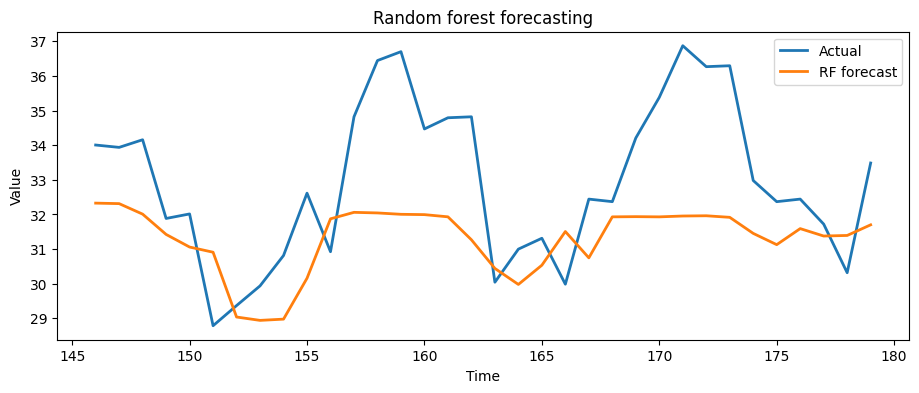

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(idx_test, y_test, label="Actual", linewidth=2)
ax.plot(idx_test, rf_pred, label="RF forecast", linewidth=2)
ax.set_title("Random forest forecasting")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
plt.show()

## Neural forecasting: Multilayer Perceptron

The MLP tutorial explores how network configuration affects forecasting performance.

In this notebook we use a compact MLP to show the idea:
- input = lagged values
- hidden layers learn nonlinear transforms
- output = next forecasted value

In [15]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=7
    ))
])

mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

mlp_results = metrics(y_test, mlp_pred, "MLP")
all_results = pd.concat(
    [baseline_results, pd.DataFrame([rf_results, mlp_results])],
    ignore_index=True
).sort_values("RMSE")
all_results

C:\Users\abpe\AppData\Local\anaconda3\envs\rise\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,MAE,RMSE
1,Seasonal naive (lag 12),1.446268,1.718300
0,Persistence (last value),1.369994,1.814346
2,Random forest,2.008936,2.414837
3,MLP,2.587184,3.070505


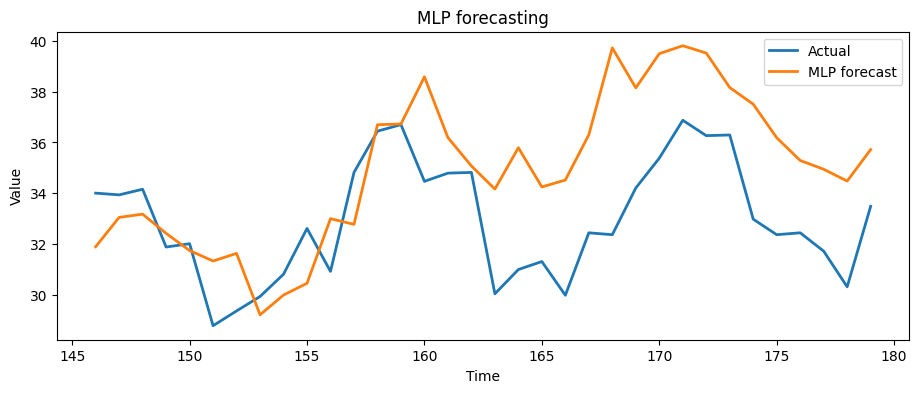

In [16]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(idx_test, y_test, label="Actual", linewidth=2)
ax.plot(idx_test, mlp_pred, label="MLP forecast", linewidth=2)
ax.set_title("MLP forecasting")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
plt.show()

In [17]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Persistence": pred_last[-len(y_test):],
    "Seasonal naive": pred_seasonal[-len(y_test):],
    "Random forest": rf_pred,
    "MLP": mlp_pred
}, index=idx_test)

comparison.head()

,Actual,Persistence,Seasonal naive,Random forest,MLP
146,34.004693,32.585073,32.240091,32.326825,31.896169
147,33.936540,34.004693,31.967574,32.312318,33.050428
148,34.156968,33.936540,33.566231,32.008940,33.177461
149,31.883898,34.156968,31.123479,31.422865,32.420922
150,32.014489,31.883898,29.088022,31.058548,31.744974


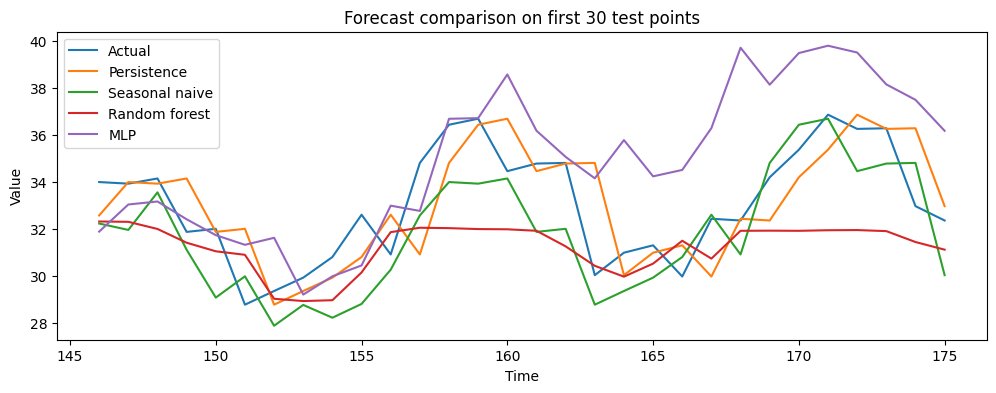

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
comparison.iloc[:30].plot(ax=ax)
ax.set_title("Forecast comparison on first 30 test points")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
plt.show()

## Error analysis

Good forecasting practice includes more than a single number.

Look at:
- MAE / RMSE
- residual distribution
- whether errors drift over time
- whether some periods are consistently under- or over-predicted

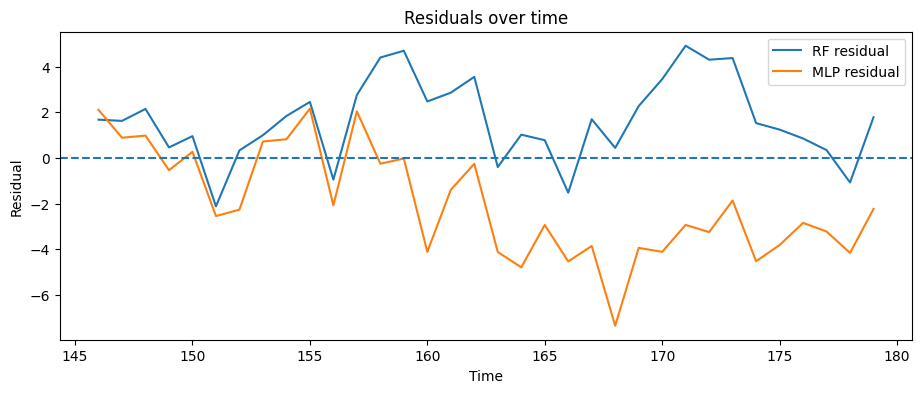

In [19]:
residual_df = pd.DataFrame({
    "RF residual": y_test - rf_pred,
    "MLP residual": y_test - mlp_pred
}, index=idx_test)

fig, ax = plt.subplots(figsize=(11, 4))
residual_df.plot(ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title("Residuals over time")
ax.set_xlabel("Time")
ax.set_ylabel("Residual")
plt.show()

C:\Users\abpe\AppData\Local\Temp\1\ipykernel_32776\1828665534.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([y_test - rf_pred, y_test - mlp_pred], labels=["RF", "MLP"])


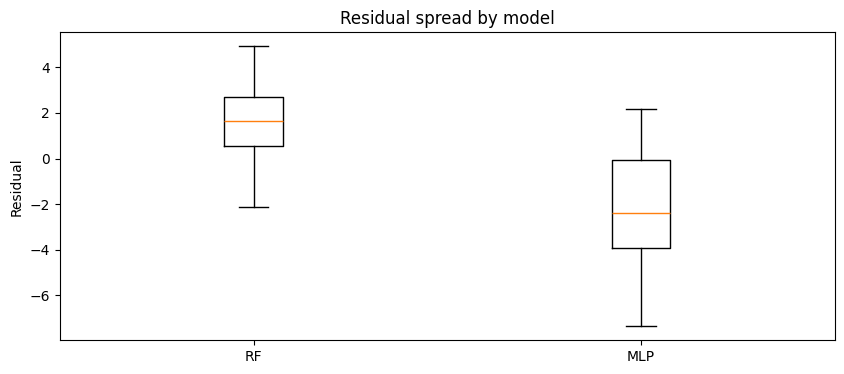

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([y_test - rf_pred, y_test - mlp_pred], labels=["RF", "MLP"])
ax.set_title("Residual spread by model")
ax.set_ylabel("Residual")
plt.show()

<font size="16"><center>Time Series Classification

## Problem framing

Instead of predicting the next numeric value, we predict a **state label**.

Example classes:
- stationary
- walking
- stairs
- transition

For many sensor problems, the raw sequence is first split into fixed-length windows, then each window is summarized by features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(4)

n_per_class = 180

def make_class(center_freq, amp, noise, slope, label, n=n_per_class):
    X = []
    y = []
    for _ in range(n):
        t = np.linspace(0, 2*np.pi, 64)
        signal = amp*np.sin(center_freq*t) + slope*np.linspace(0, 1, len(t)) + np.random.normal(0, noise, len(t))
        X.append(signal)
        y.append(label)
    return np.array(X), np.array(y)

X0, y0 = make_class(0.3, 0.2, 0.08, 0.0, "stationary")
X1, y1 = make_class(1.0, 0.7, 0.12, 0.15, "walking")
X2, y2 = make_class(1.8, 1.0, 0.18, 0.35, "stairs")
X3, y3 = make_class(2.5, 0.5, 0.10, -0.05, "transition")

X_raw = np.vstack([X0, X1, X2, X3])
y = np.concatenate([y0, y1, y2, y3])

X_raw.shape, y.shape

((720, 64), (720,))

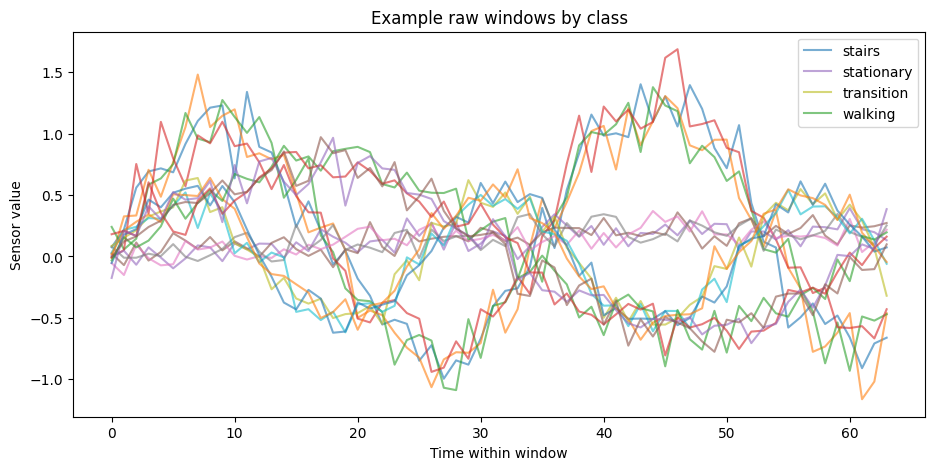

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
for label in np.unique(y):
    idx = np.where(y == label)[0][:4]
    for i in idx:
        ax.plot(X_raw[i], alpha=0.6, label=label if i == idx[0] else None)

ax.set_title("Example raw windows by class")
ax.set_xlabel("Time within window")
ax.set_ylabel("Sensor value")
ax.legend()
plt.show()

## Handcrafted window features

We summarize each 64-sample window with simple features:
- mean
- standard deviation
- min / max
- peak-to-peak range
- energy
- first-difference variability
- zero-crossing count

This is a common classical pipeline for wearable and biomedical time series.

In [3]:
def extract_features(window):
    diff = np.diff(window)
    return {
        "mean": np.mean(window),
        "std": np.std(window),
        "min": np.min(window),
        "max": np.max(window),
        "ptp": np.ptp(window),
        "energy": np.sum(window**2),
        "diff_std": np.std(diff),
        "zero_crossings": np.sum(np.diff(np.signbit(window)) != 0)
    }

X_feat = pd.DataFrame([extract_features(w) for w in X_raw])
X_feat.head()

,mean,std,min,max,ptp,energy,diff_std,zero_crossings
0,0.141469,0.104626,-0.096958,0.393112,0.490070,1.981451,0.119148,10
1,0.148594,0.096807,-0.087802,0.358804,0.446606,2.012904,0.103937,8
2,0.132017,0.105137,-0.151298,0.369852,0.521150,1.822870,0.103973,7
3,0.146699,0.105573,-0.041290,0.345795,0.387085,2.090645,0.116275,8
4,0.163564,0.113644,-0.060150,0.408372,0.468522,2.538777,0.126716,7


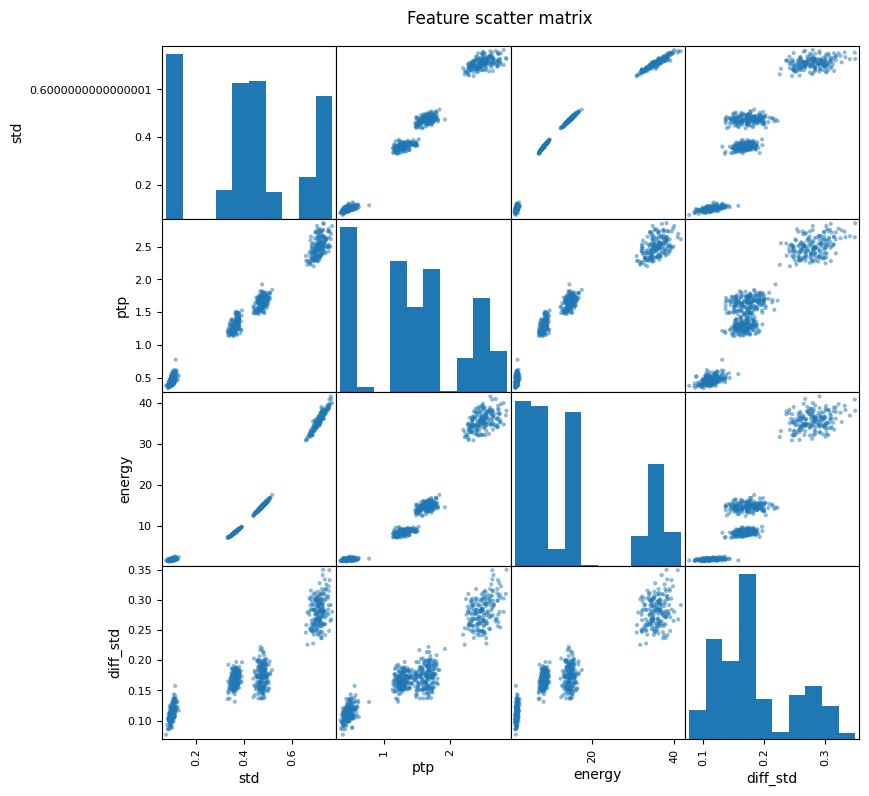

In [4]:
from pandas.plotting import scatter_matrix

sampled = X_feat.copy()
sampled["label"] = y
colors = sampled["label"].map({
    "stationary":"tab:blue",
    "walking":"tab:orange",
    "stairs":"tab:green",
    "transition":"tab:red"
})

axes = scatter_matrix(X_feat[["std","ptp","energy","diff_std"]], figsize=(9, 9), diagonal="hist")
plt.suptitle("Feature scatter matrix", y=0.92)
plt.show()

## Train / test split and models

We compare:
- logistic regression
- random forest
- support vector machine

For sensor problems, the best model often depends on:
- feature quality
- class overlap
- dataset size
- subject variability

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.25, random_state=4, stratify=y
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=4),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=4))
    ])
}

rows = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted[name] = model
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro F1": f1_score(y_test, pred, average="macro")
    })

results = pd.DataFrame(rows).sort_values("Macro F1", ascending=False)
results

,Model,Accuracy,Macro F1
0,Logistic Regression,1.0,1.0
1,Random Forest,1.0,1.0
2,SVM,1.0,1.0


In [6]:
best_name = results.iloc[0]["Model"]
best_model = fitted[best_name]
best_pred = best_model.predict(X_test)

print("Best model:", best_name)
print()
print(classification_report(y_test, best_pred))

Best model: Logistic Regression

              precision    recall  f1-score   support

      stairs       1.00      1.00      1.00        45
  stationary       1.00      1.00      1.00        45
  transition       1.00      1.00      1.00        45
     walking       1.00      1.00      1.00        45

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



<function matplotlib.pyplot.show(close=None, block=None)>

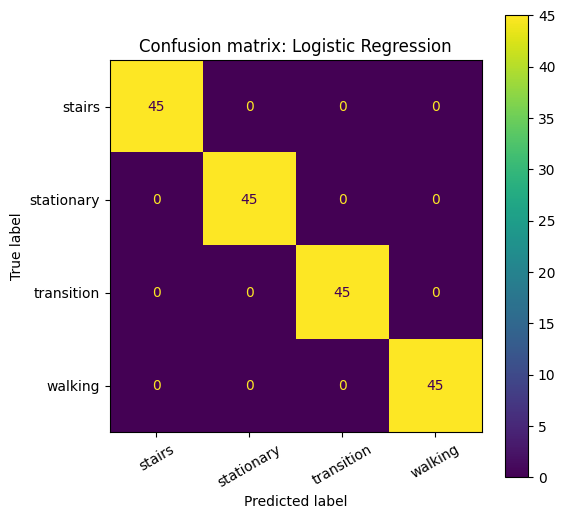

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, xticks_rotation=30, ax=ax)
ax.set_title(f"Confusion matrix: {best_name}")
plt.show

<font size="25"><center>Thank you!